# 3.1 Newspapers — EDA

Loads MediaCloud articles (187 outlets, ~235,000 articles), assigns political leaning to each source, standardises columns, applies text cleaning, and writes the Silver-layer parquet.

**Input:** `Data/1_Bronze/Newspapers/`  
**Output:** `Data/2_Silver/Newspapers/mediacloud_articles_clean.csv`


<!-- toc -->
## Contents
- [Setup](#setup)
- [1. Assign Political Leaning](#1-assign-political-leaning)
- [2. Standardise Columns](#2-standardise-columns)
- [3. Sort & Inspect](#3-sort-inspect)
  - [3a. Clean Source Names](#3a-clean-source-names)
  - [3b. Text Preprocessing](#3b-text-preprocessing)
- [4. Save to Silver Layer](#4-save-to-silver-layer)
- [5. Quick Overview](#5-quick-overview)


## Setup

In [9]:
import pandas as pd
import shutil, os, sys
from pathlib import Path

# Find project root (folder containing Data/)
_root = Path(os.getcwd())
for _ in range(5):
    if (_root / "Data").exists():
        break
    _root = _root.parent

sys.path.insert(0, str(_root))

from Functions.text_preprocessing import apply_text_cleaning
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from house_style import *
apply_style()

BRONZE         = _root / "Data" / "1_Bronze" / "Newspapers"
SILVER         = _root / "Data" / "2_Silver" / "Newspapers"
SILVER_STORAGE = SILVER / "Storage"
SILVER.mkdir(parents=True, exist_ok=True)
SILVER_STORAGE.mkdir(parents=True, exist_ok=True)

print(f"Root   : {_root}")
print(f"Bronze : {BRONZE}")
print(f"Silver : {SILVER}")

Root   : c:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA
Bronze : c:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA\Data\1_Bronze\Newspapers
Silver : c:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA\Data\2_Silver\Newspapers


In [10]:
df_mc = pd.read_csv(BRONZE / "mediacloud_stories.csv", parse_dates=["date"])
print(f"MediaCloud articles : {len(df_mc):,}")
print(f"Unique sources      : {df_mc['source'].nunique()}")
df_mc.head(3)


MediaCloud articles : 156,914
Unique sources      : 187


,date,query,title,url,source,pub_date
0,2024-07-05,trump,5 candidates who could replace Biden as 2024 D...,https://www.syracuse.com/us-news/2024/07/5-can...,syracuse.com,2024-07-05
1,2024-07-05,trump,Federal Reserve highlights its political indep...,https://www.startribune.com/federal-reserve-hi...,startribune.com,2024-07-05
2,2024-07-05,trump,US Supreme Court: 10 days of blockbuster decis...,https://theconversation.com/us-supreme-court-1...,theconversation.com,2024-07-05


## 1. Assign Political Leaning

Maps each MediaCloud outlet to one of three political leanings (Democratic · Republican · Center/Unknown) using the outlet’s domain name.

In [11]:
DEMOCRATIC = {
    # Major national outlets
    "nytimes.com", "theguardian.com", "washingtonpost.com", "cnn.com",
    "nbcnews.com", "cbsnews.com", "abcnews.go.com", "msnbc.com",
    "latimes.com", "bostonglobe.com", "npr.org", "pbs.org",
    # Left-leaning commentary & news
    "rawstory.com", "huffpost.com", "dailykos.com", "alternet.org",
    "salon.com", "thedailybeast.com", "thenation.com", "theatlantic.com",
    "motherjones.com", "slate.com", "vox.com", "newyorker.com",
    "talkingpointsmemo.com", "nationalmemo.com", "theroot.com",
    "theintercept.com", "opednews.com", "newsone.com", "therealnews.com",
    "rollingstone.com", "vanityfair.com", "grist.org", "schwartzreport.net",
    "mintpressnews.com", "propublica.org", "theconversation.com",
    "buzzfeed.com", "businessinsider.com",
}

REPUBLICAN = {
    # Major right-leaning outlets
    "foxnews.com", "foxbusiness.com", "breitbart.com", "nypost.com",
    "dailycaller.com", "washingtonexaminer.com",
    # Conservative commentary & news
    "redstate.com", "townhall.com", "pjmedia.com", "hotair.com",
    "newsbusters.org", "theblaze.com", "oann.com", "patriotpost.us",
    "spectator.org", "dailysignal.com", "ncregister.com",
    "americanfreepress.net", "newsblaze.com",
}

def assign_leaning(source):
    if source in DEMOCRATIC:
        return "Democratic"
    elif source in REPUBLICAN:
        return "Republican"
    else:
        return "Center/Unknown"

df_mc["leaning"] = df_mc["source"].apply(assign_leaning)

print("MediaCloud leaning distribution:")
print(df_mc.groupby('leaning').size().to_string())
print(f"\nCoverage: {df_mc[df_mc['leaning']!='Center/Unknown']['source'].nunique()} classified, "
      f"{df_mc[df_mc['leaning']=='Center/Unknown']['source'].nunique()} center/unknown sources")

MediaCloud leaning distribution:
leaning
Center/Unknown    68214
Democratic        55995
Republican        32705

Coverage: 56 classified, 131 center/unknown sources


## 2. Standardise Columns

In [12]:
COLS = ["source", "leaning", "date", "title", "url"]

# Behoud enkel de 5 relevante kolommen (verwijder 'query' en 'pub_date')
df_mc_clean = df_mc[COLS].copy()

print("Kolommen:", df_mc_clean.columns.tolist())
df_mc_clean.head(3)


Kolommen: ['source', 'leaning', 'date', 'title', 'url']


,source,leaning,date,title,url
0,syracuse.com,Center/Unknown,2024-07-05,5 candidates who could replace Biden as 2024 D...,https://www.syracuse.com/us-news/2024/07/5-can...
1,startribune.com,Center/Unknown,2024-07-05,Federal Reserve highlights its political indep...,https://www.startribune.com/federal-reserve-hi...
2,theconversation.com,Democratic,2024-07-05,US Supreme Court: 10 days of blockbuster decis...,https://theconversation.com/us-supreme-court-1...


## 3. Sort & Inspect

In [13]:
df_all = df_mc_clean.copy()

# Datums normaliseren
df_all["date"] = pd.to_datetime(df_all["date"], errors="coerce")
df_all = df_all.sort_values("date").reset_index(drop=True)

print("=== MediaCloud dataset ===")
print(df_all.groupby("leaning").size().to_string())
print()
print(df_all.groupby(["source", "leaning"]).size().sort_values(ascending=False).head(20).to_string())
print(f"\nDatum range : {df_all['date'].min().date()} -> {df_all['date'].max().date()}")
df_all.head()

=== MediaCloud dataset ===
leaning
Center/Unknown    68214
Democratic        55995
Republican        32705

source             leaning       
newsweek.com       Center/Unknown    6985
rawstory.com       Democratic        6695
cbsnews.com        Democratic        6272
foxnews.com        Republican        5770
breitbart.com      Republican        5640
abcnews.go.com     Democratic        4889
nypost.com         Republican        4579
inquirer.com       Center/Unknown    4281
nytimes.com        Democratic        3594
politicalwire.com  Center/Unknown    3509
theguardian.com    Democratic        3364
ibtimes.com        Center/Unknown    3323
benzinga.com       Center/Unknown    3196
dailycaller.com    Republican        3169
ajc.com            Center/Unknown    3117
newsday.com        Center/Unknown    3043
forbes.com         Center/Unknown    2975
huffpost.com       Democratic        2969
redstate.com       Republican        2952
cnn.com            Democratic        2725

Datum range : 202

,source,leaning,date,title,url
0,syracuse.com,Center/Unknown,2024-07-05,5 candidates who could replace Biden as 2024 D...,https://www.syracuse.com/us-news/2024/07/5-can...
1,mlive.com,Center/Unknown,2024-07-05,5 takeaways from President Biden’s July campai...,https://www.mlive.com/politics/2024/07/5-takea...
2,marketwatch.com,Center/Unknown,2024-07-05,"What it’s like to be audited by the bigger, be...",https://www.marketwatch.com/story/how-the-irs-...
3,foxnews.com,Republican,2024-07-05,Democrats are setting up Trump for an economic...,https://www.foxnews.com/opinion/democrats-sett...
4,foxnews.com,Republican,2024-07-05,What would a President Pritzker do on immigrat...,https://www.foxnews.com/politics/what-would-pr...


### 3a. Clean Source Names

In [14]:
SOURCE_NAMES = {
    # ── MediaCloud domains → clean names ──────────────────────────────────────
    "nytimes.com":             "New York Times",
    "theguardian.com":         "The Guardian",
    "washingtonpost.com":      "Washington Post",
    "cnn.com":                 "CNN",
    "nbcnews.com":             "NBC News",
    "cbsnews.com":             "CBS News",
    "abcnews.go.com":          "ABC News",
    "msnbc.com":               "MSNBC",
    "latimes.com":             "Los Angeles Times",
    "bostonglobe.com":         "Boston Globe",
    "npr.org":                 "NPR",
    "pbs.org":                 "PBS",
    "rawstory.com":            "Raw Story",
    "huffpost.com":            "HuffPost",
    "dailykos.com":            "Daily Kos",
    "alternet.org":            "AlterNet",
    "salon.com":               "Salon",
    "thedailybeast.com":       "The Daily Beast",
    "thenation.com":           "The Nation",
    "theatlantic.com":         "The Atlantic",
    "motherjones.com":         "Mother Jones",
    "slate.com":               "Slate",
    "vox.com":                 "Vox",
    "newyorker.com":           "The New Yorker",
    "talkingpointsmemo.com":   "Talking Points Memo",
    "nationalmemo.com":        "National Memo",
    "theroot.com":             "The Root",
    "theintercept.com":        "The Intercept",
    "opednews.com":            "OpEd News",
    "newsone.com":             "NewsOne",
    "therealnews.com":         "The Real News",
    "rollingstone.com":        "Rolling Stone",
    "vanityfair.com":          "Vanity Fair",
    "grist.org":               "Grist",
    "schwartzreport.net":      "Schwartz Report",
    "mintpressnews.com":       "MintPress News",
    "propublica.org":          "ProPublica",
    "theconversation.com":     "The Conversation",
    "buzzfeed.com":            "BuzzFeed News",
    "businessinsider.com":     "Business Insider",
    "foxnews.com":             "Fox News",
    "foxbusiness.com":         "Fox Business",
    "breitbart.com":           "Breitbart",
    "nypost.com":              "NY Post",
    "dailycaller.com":         "Daily Caller",
    "washingtonexaminer.com":  "Washington Examiner",
    "redstate.com":            "RedState",
    "townhall.com":            "Townhall",
    "pjmedia.com":             "PJ Media",
    "hotair.com":              "Hot Air",
    "newsbusters.org":         "NewsBusters",
    "theblaze.com":            "The Blaze",
    "oann.com":                "OAN",
    "patriotpost.us":          "Patriot Post",
    "spectator.org":           "The American Spectator",
    "dailysignal.com":         "The Daily Signal",
    "ncregister.com":          "National Catholic Register",
    "americanfreepress.net":   "American Free Press",
    "newsblaze.com":           "NewsBlaze",
    "newsweek.com":            "Newsweek",
    "inquirer.com":            "Philadelphia Inquirer",
    "politicalwire.com":       "Political Wire",
    "benzinga.com":            "Benzinga",
    "ibtimes.com":             "International Business Times",
    "ajc.com":                 "Atlanta Journal-Constitution",
    "forbes.com":              "Forbes",
    "newsday.com":             "Newsday",
    "realclearpolitics.com":   "RealClearPolitics",
    "usatoday.com":            "USA Today",
    "sun-sentinel.com":        "Sun Sentinel",
    "pbs.org":                 "PBS",
    "inquisitr.com":           "The Inquisitr",
    "hotair.com":              "Hot Air",
    "time.com":                "Time",
    "chicagotribune.com":      "Chicago Tribune",
    "mercurynews.com":         "Mercury News",
    "fortune.com":             "Fortune",
    "startribune.com":         "Star Tribune",
    "twincities.com":          "Twin Cities Pioneer Press",
    "sandiegouniontribune.com":"San Diego Union-Tribune",
    "arkansasonline.com":      "Arkansas Democrat-Gazette",
    "thewrap.com":             "The Wrap",
    "ocregister.com":          "OC Register",
    "courant.com":             "Hartford Courant",
    "theweek.com":             "The Week",
    "cleveland.com":           "Cleveland Plain Dealer",
    "centralmaine.com":        "Central Maine",
    "staradvertiser.com":      "Honolulu Star-Advertiser",
    "newsone.com":             "NewsOne",
    "orlandosentinel.com":     "Orlando Sentinel",
    "seattletimes.com":        "Seattle Times",
    "hollywoodreporter.com":   "Hollywood Reporter",
    "upi.com":                 "UPI",
    "motherjones.com":         "Mother Jones",
    "foxbusiness.com":         "Fox Business",
    "variety.com":             "Variety",
    "mlive.com":               "MLive",
    "pilotonline.com":         "The Virginian-Pilot",
    "tmz.com":                 "TMZ",
    "reuters.com":             "Reuters",
    "denverpost.com":          "Denver Post",
    "dailydot.com":            "The Daily Dot",
    "marketwatch.com":         "MarketWatch",
    "rollcall.com":            "Roll Call",
    "azcentral.com":           "AZCentral",
    "qz.com":                  "Quartz",
    "billboard.com":           "Billboard",
    "radaronline.com":         "Radar Online",
    "oregonlive.com":          "OregonLive",
    "theroot.com":             "The Root",
    "people.com":              "People",
    "syracuse.com":            "Syracuse.com",
    "jsonline.com":            "Milwaukee Journal Sentinel",
    "freep.com":               "Detroit Free Press",
    "stltoday.com":            "St. Louis Post-Dispatch",
    "cnbc.com":                "CNBC",
    "hollywoodlife.com":       "Hollywood Life",
    "wired.com":               "Wired",
    "csmonitor.com":           "Christian Science Monitor",
    "ncronline.org":           "National Catholic Reporter",
    "gizmodo.com":             "Gizmodo",
    "postandcourier.com":      "Post and Courier",
    "ew.com":                  "Entertainment Weekly",
    "dispatch.com":            "The Dispatch",
    "investors.com":           "Investor's Business Daily",
    "rttnews.com":             "RTTNews",
    "recorder.com":            "The Recorder",
    "thestreet.com":           "The Street",
    "factcheck.org":           "FactCheck.org",
    "theverge.com":            "The Verge",
    "politico.com":            "Politico",
    "gazettenet.com":          "Daily Hampshire Gazette",
    "mashable.com":            "Mashable",
    "bloomberg.com":           "Bloomberg",
    "stripes.com":             "Stars and Stripes",
    "berkshireeagle.com":      "Berkshire Eagle",
    "omaha.com":               "Omaha World-Herald",
    "cnet.com":                "CNET",
    "tampabay.com":            "Tampa Bay Times",
    "indystar.com":            "Indianapolis Star",
    "techcrunch.com":          "TechCrunch",
    "indiewire.com":           "IndieWire",
    "eurweb.com":              "EURweb",
    "scientificamerican.com":  "Scientific American",
    "uproxx.com":              "Uproxx",
    "armytimes.com":           "Army Times",
    "propublica.org":          "ProPublica",
    "airforcetimes.com":       "Air Force Times",
    "navytimes.com":           "Navy Times",
    "eonline.com":             "E! Online",
    "engadget.com":            "Engadget",
    "espn.com":                "ESPN",
    "techradar.com":           "TechRadar",
    "gq.com":                  "GQ",
    "nhgazette.com":           "New Hampshire Gazette",
    "refinery29.com":          "Refinery29",
    "elnuevodia.com":          "El Nuevo Día",
    "pressrepublican.com":     "Press-Republican",
    "rutlandherald.com":       "Rutland Herald",
    "arstechnica.com":         "Ars Technica",
    "pitchfork.com":           "Pitchfork",
    "sbnation.com":            "SB Nation",
    "usmagazine.com":          "Us Weekly",
    "fansided.com":            "FanSided",
    "augustachronicle.com":    "Augusta Chronicle",
    "deadspin.com":            "Deadspin",
    "eater.com":               "Eater",
    "ign.com":                 "IGN",
    "harpers.org":             "Harper's Magazine",
    "observer.com":            "Observer",
    "bustle.com":              "Bustle",
    "popmatters.com":          "PopMatters",
    "creators.com":            "Creators Syndicate",
    "foxsports.com":           "Fox Sports",
    "bizjournals.com":         "Business Journals",
    "cherokeephoenix.org":     "Cherokee Phoenix",
    "polygon.com":             "Polygon",
    "opensecrets.org":         "OpenSecrets",
    "mongabay.com":            "Mongabay",
    "thrillist.com":           "Thrillist",
    "zdnet.com":               "ZDNet",
    "saturdayeveningpost.com": "Saturday Evening Post",
    "monstersandcritics.com":  "Monsters & Critics",
    "vice.com":                "Vice",
    "jezebel.com":             "Jezebel",
    "nbcsports.com":           "NBC Sports",
    "post-gazette.com":        "Pittsburgh Post-Gazette",
    "chron.com":               "Houston Chronicle",
    "elitedaily.com":          "Elite Daily",
    "opposingviews.com":       "Opposing Views",
    "parade.com":              "Parade",
    "usnews.com":              "U.S. News & World Report",
    "baltimoresun.com":        "Baltimore Sun",
    "bleacherreport.com":      "Bleacher Report",
    "cincinnati.com":          "Cincinnati Enquirer",
    "cbssports.com":           "CBS Sports",
    "sportingnews.com":        "Sporting News",
}

def clean_source(name):
    return SOURCE_NAMES.get(name, name)  # fallback: keep original if not in mapping

df_all["source"] = df_all["source"].apply(clean_source)

# Verify
print("Sample cleaned sources:")
print(df_all[["source", "leaning"]].drop_duplicates("source").sort_values("source").head(20).to_string())
print(f"\nUnique sources after cleaning: {df_all['source'].nunique()}")

Sample cleaned sources:
                             source         leaning
13                         ABC News      Democratic
71071                     AZCentral  Center/Unknown
2311                Air Force Times  Center/Unknown
67                         AlterNet      Democratic
28187           American Free Press      Republican
692       Arkansas Democrat-Gazette  Center/Unknown
2195                     Army Times  Center/Unknown
4545                   Ars Technica  Center/Unknown
10221  Atlanta Journal-Constitution  Center/Unknown
79136             Augusta Chronicle  Center/Unknown
10                    Baltimore Sun  Center/Unknown
9                          Benzinga  Center/Unknown
72366               Berkshire Eagle  Center/Unknown
576                       Billboard  Center/Unknown
884                 Bleacher Report  Center/Unknown
16360                     Bloomberg  Center/Unknown
5206                   Boston Globe      Democratic
29                        Breitbart     

### 3b. Text Preprocessing

Apply `apply_text_cleaning` on the `title` column: filters to English only and adds `title_clean`.

In [15]:
df_all = apply_text_cleaning(df_all, text_col="title", output_col="title_clean", filter_english=True)

print(df_all[["title", "title_clean", "word_count", "leaning"]].head(3).to_string())

Detecting language for 156,914 rows (this may take a moment)...
✓ Language filter: kept 153,487 English rows (dropped 3,427 non-English, 2.2%)
✓ Cleaned 'title' → 'title_clean'
  Rows       : 153,487
  Avg words  : 8.4
  Empty texts: 3

                                         title_clean  word_count
0  candidates could replace biden democratic pres...           7
1  takeaways president biden july campaign stop d...           7
2  like audited bigger better funded irs pushing ...           8
                                                                                           title                                                     title_clean  word_count         leaning
0                   5 candidates who could replace Biden as 2024 Democratic presidential nominee  candidates could replace biden democratic presidential nominee           7  Center/Unknown
1                               5 takeaways from President Biden’s July campaign stop in Detroit            takeaways preside

## 4. Save to Silver Layer

In [16]:
df_all.to_csv(SILVER / "mediacloud_articles_clean.csv", index=False)
print(f"Saved: mediacloud_articles_clean.csv  ({len(df_all):,} articles, columns: {list(df_all.columns)})")

Saved: mediacloud_articles_clean.csv  (153,487 articles, columns: ['source', 'leaning', 'date', 'title', 'url', 'detected_lang', 'title_clean', 'words', 'word_count'])


## 5. Quick Overview

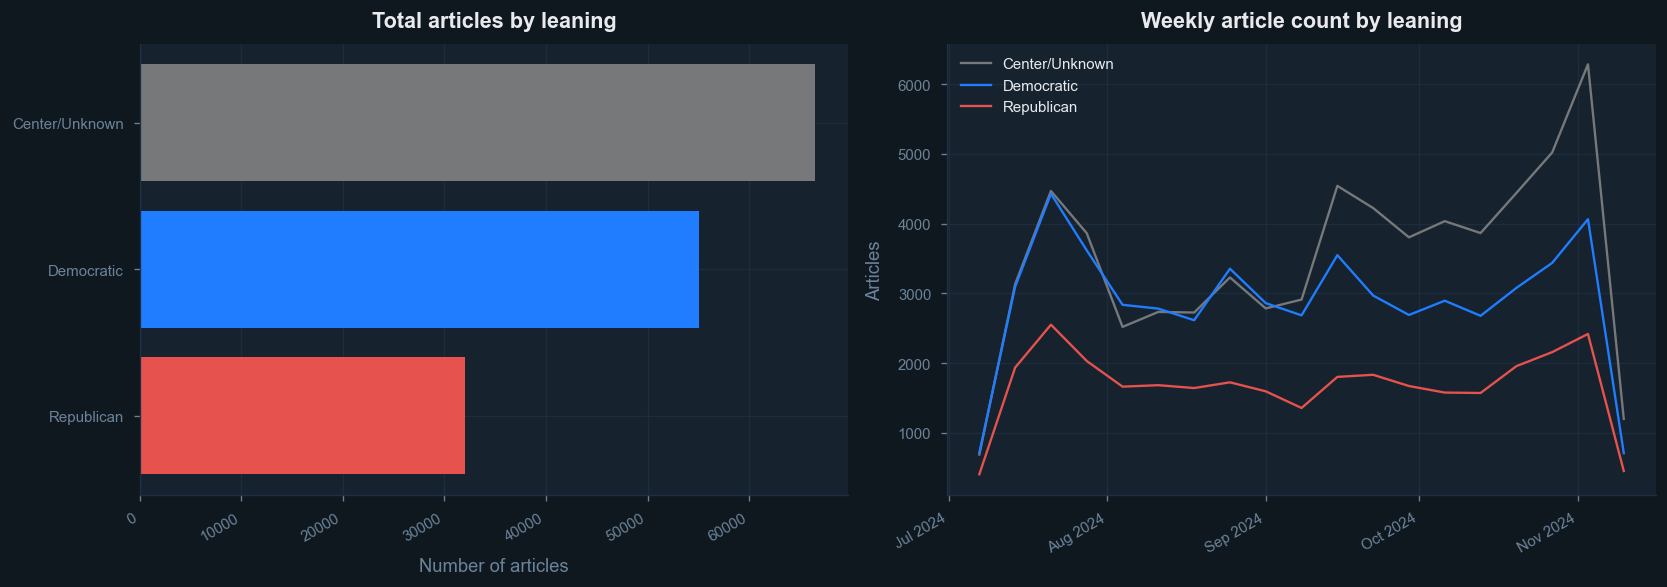


Final dataset: 153,487 articles from 187 sources


In [19]:
from house_style import DEMOCRAT, REPUBLICAN, NEUTRAL, TEXT_PRIMARY, TEXT_MUTED, apply_style
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
apply_style()

COLORS = {"Democratic": DEMOCRAT, "Republican": REPUBLICAN, "Center/Unknown": NEUTRAL}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total articles by leaning
counts = df_all.groupby("leaning").size().sort_values()
axes[0].barh(counts.index, counts.values,
             color=[COLORS[l] for l in counts.index])
axes[0].set_title("Total articles by leaning", color=TEXT_PRIMARY, pad=10)
axes[0].set_xlabel("Number of articles", color=TEXT_MUTED)
axes[0].tick_params(colors=TEXT_MUTED)

# Weekly article count by leaning
df_all["week"] = df_all["date"].dt.to_period("W").dt.start_time
weekly = df_all.groupby(["week", "leaning"]).size().unstack(fill_value=0).resample("W").sum()
for leaning in weekly.columns:
    axes[1].plot(weekly.index, weekly[leaning], label=leaning,
                 color=COLORS.get(leaning, NEUTRAL), linewidth=1.4)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].set_title("Weekly article count by leaning", color=TEXT_PRIMARY, pad=10)
axes[1].set_ylabel("Articles", color=TEXT_MUTED)
axes[1].legend(frameon=False, labelcolor=TEXT_PRIMARY)
fig.autofmt_xdate()

plt.tight_layout()
plt.savefig(SILVER / "newspaper_combined_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nFinal dataset: {len(df_all):,} articles from {df_all['source'].nunique()} sources")